In [1]:
columns = ["engine_id", "cycle"] 
columns += [f"setting_{i}" for i in range(1, 4)]
columns += [f"sensor_{i}" for i in range(1, 22)]

In [2]:
import pandas as pd

train_path = "data/train_FD001.txt"

train_df = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None
)

train_df.columns = columns

In [3]:
print(train_df.head())
print(train_df.shape)
print(train_df.info())

   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1      2     0.0019    -0.0003      100.0    518.67    642.15   
2          1      3    -0.0043     0.0003      100.0    518.67    642.35   
3          1      4     0.0007     0.0000      100.0    518.67    642.35   
4          1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0     8.4195       0.03

In [4]:
train_df.describe()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


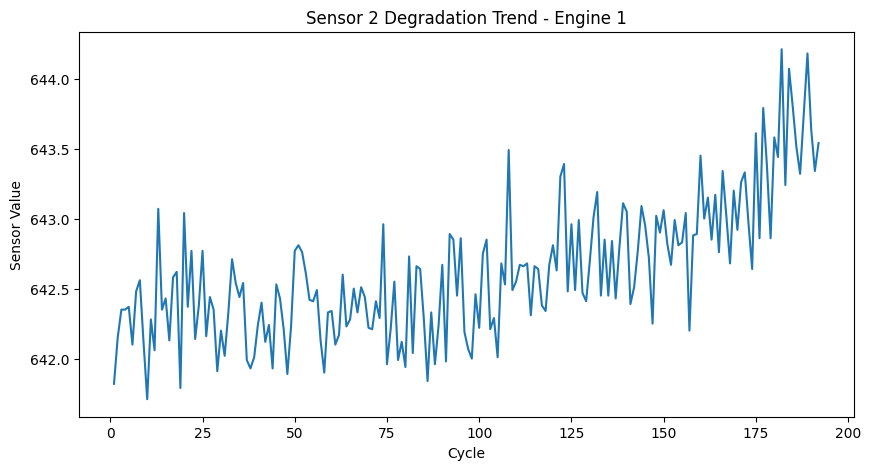

In [5]:
import matplotlib.pyplot as plt

engine_1 = train_df[train_df["engine_id"] == 1]

plt.figure(figsize=(10,5))
plt.plot(engine_1["cycle"], engine_1["sensor_2"])

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.title("Sensor 2 Degradation Trend - Engine 1")

plt.show()

In [6]:
max_cycles = train_df.groupby("engine_id")["cycle"].max().reset_index()
max_cycles.columns = ["engine_id", "max_cycle"]

train_df = train_df.merge(max_cycles, on="engine_id")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]

train_df.drop("max_cycle", axis=1, inplace=True)

In [10]:
train_df.to_csv("data/train_fd001_with_rul.csv", index=False)